In [1]:
import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch, Rectangle
from scipy.optimize import curve_fit
from scipy.stats import poisson
import pandas as pd

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
OUT_DIR = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks")
os.makedirs(OUT_DIR, exist_ok=True)

CHIPS = ["hexitec", "medipix3", "eiger2"]
CHIP_LABELS = {"hexitec": "HEXITEC", "medipix3": "Medipix3", "eiger2": "EIGER2"}
CDTE_IONISATION_EV = 4.4

# Detector names inside each ROOT file - matches the [chip]_detector convention
# used in the run script
DET_NAME = {chip: f"{chip}_detector" for chip in CHIPS}

# Chip parameters (for reference tables/labels, not re-simulation)
CHIP_PARAMS = {
    "hexitec":  {"pixels": "80x80", "pitch_um": 250, "thickness_um": 1000,
                 "noise_e": 20, "threshold_e": 795, "smearing_e": 20,
                 "bias_V": 500},
    "medipix3": {"pixels": "256x256", "pitch_um": 55, "thickness_um": 300,
                 "noise_e": 80, "threshold_e": 700, "smearing_e": 35,
                 "bias_V": 500},
    "eiger2":   {"pixels": "256x256 (rep.)", "pitch_um": 75, "thickness_um": 750,
                 "noise_e": 91, "threshold_e": 909, "smearing_e": 114,
                 "bias_V": 400},
}

# Colour scheme - consistent with all prior dashboards
NAVY, WHITE, LGRAY, GRAY = "#0B1F3A", "#F8FAFC", "#CBD5E1", "#64748B"
TEAL, BLUE, PURP, AMBER, RED, GREEN = "#0D9488", "#0369A1", "#7C3AED", "#D97706", "#DC2626", "#16A34A"
CHIP_COLORS = {"hexitec": TEAL, "medipix3": BLUE, "eiger2": PURP}

def style_ax(ax, title):
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY, labelsize=9)
    ax.xaxis.label.set_color(LGRAY); ax.yaxis.label.set_color(LGRAY)
    ax.title.set_color(WHITE)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

print("Setup complete.")
print("\nChip parameter reference:")
pd.DataFrame(CHIP_PARAMS).T

Setup complete.

Chip parameter reference:


,pixels,pitch_um,thickness_um,noise_e,threshold_e,smearing_e,bias_V
hexitec,80x80,250,1000,20,795,20,500
medipix3,256x256,55,300,80,700,35,500
eiger2,256x256 (rep.),75,750,91,909,114,400


In [2]:
def load_root(path, det_name):
    """Load pixel_charge, cluster_charge, cluster_size, hit_map from a ROOT file."""
    f = uproot.open(path)
    pc = f[f"DetectorHistogrammer/{det_name}/charge/pixel_charge;1"].to_numpy()
    cc = f[f"DetectorHistogrammer/{det_name}/charge/cluster_charge;1"].to_numpy()
    cs = f[f"DetectorHistogrammer/{det_name}/cluster_size/cluster_size;1"].to_numpy()
    hm = f[f"DetectorHistogrammer/{det_name}/hit_map;1"].to_numpy()
    return {"pixel_charge": pc, "cluster_charge": cc, "cluster_size": cs,
            "hit_map": hm, "clusters": int(cs[0].sum()), "hits": int(pc[0].sum())}

def safe_load(path, det_name):
    if not os.path.exists(path):
        print(f"  MISSING: {path}")
        return None
    try:
        return load_root(path, det_name)
    except Exception as e:
        print(f"  ERROR loading {path}: {e}")
        return None

def bhattacharyya(hist1, hist2):
    p = hist1 / (hist1.sum() + 1e-12)
    q = hist2 / (hist2.sum() + 1e-12)
    bc = min(np.sum(np.sqrt(p * q)), 1.0)
    return -np.log(bc + 1e-12)

def trapezoid_area(y, x):
    y, x = np.asarray(y), np.asarray(x)
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2.0)

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def fit_photopeak(cluster_charge, energy_keV, search_window_pct=0.25, fit_halfwidth=15):
    """
    Fits a Gaussian to the photopeak, searching near the physics-predicted
    location (energy / 4.4 eV) rather than a blind percentage cutoff.
    Returns dict with fwhm_keV, resolution_pct, peak_charge_ke, and fit
    arrays for verification plotting - or None if the fit fails/is unreliable.
    """
    counts, edges = cluster_charge[0], cluster_charge[1]
    centres = (edges[:-1] + edges[1:]) / 2
    if counts.sum() < 20:
        return None

    expected_ke = (energy_keV * 1000 / CDTE_IONISATION_EV) / 1000
    mask = (centres > expected_ke * (1 - search_window_pct)) & \
           (centres < expected_ke * (1 + search_window_pct))
    if counts[mask].sum() < 5:
        return None

    idxs = np.where(mask)[0]
    peak_idx = idxs[np.argmax(counts[mask])]
    peak_charge = centres[peak_idx]

    lo = max(0, peak_idx - fit_halfwidth)
    hi = min(len(counts), peak_idx + fit_halfwidth)
    x_fit, y_fit = centres[lo:hi], counts[lo:hi]
    if y_fit.sum() < 5:
        return None

    try:
        sigma_guess = max((edges[hi-1] - edges[lo]) / 6, 0.1)
        popt, _ = curve_fit(gaussian, x_fit, y_fit,
                             p0=[y_fit.max(), peak_charge, sigma_guess], maxfev=5000)
        sigma_ke = abs(popt[2])
        fwhm_keV = sigma_ke * 2.355 * CDTE_IONISATION_EV
        return {
            "expected_ke": expected_ke, "peak_charge_ke": peak_charge,
            "fwhm_keV": fwhm_keV, "resolution_pct": (fwhm_keV / energy_keV) * 100,
            "fit_x": x_fit, "fit_y": y_fit, "popt": popt,
            "all_centres": centres, "all_counts": counts,
        }
    except Exception:
        return None

print("Helper functions defined.")

Helper functions defined.


In [3]:
MATERIALS = ["steel", "bone", "glass", "stone", "rubber"]
MATERIAL_THICKNESS = {"steel": "1mm", "bone": "5mm", "glass": "5mm",
                       "stone": "5mm", "rubber": "5mm"}

cat1_data = {}
clean_bg = {}

for chip in CHIPS:
    det = DET_NAME[chip]
    bg_path = os.path.join(BASE, f"cat3_{chip}_clean_background.root")
    clean_bg[chip] = safe_load(bg_path, det)

    for mat in MATERIALS:
        path = os.path.join(BASE, f"cat1_{chip}_60keV_{mat}.root")
        data = safe_load(path, det)
        if data:
            cat1_data[(chip, mat)] = data
            print(f"  {chip} / {mat}: {data['clusters']:,} clusters")

print(f"\nLoaded {len(cat1_data)} material combinations, {sum(v is not None for v in clean_bg.values())} clean backgrounds.")

  hexitec / steel: 3,826 clusters
  hexitec / bone: 7,321 clusters
  hexitec / glass: 7,567 clusters
  hexitec / stone: 7,294 clusters
  hexitec / rubber: 8,809 clusters
  medipix3 / steel: 3,204 clusters
  medipix3 / bone: 6,142 clusters
  medipix3 / glass: 6,344 clusters
  medipix3 / stone: 6,121 clusters
  medipix3 / rubber: 7,376 clusters
  eiger2 / steel: 4,176 clusters
  eiger2 / bone: 7,992 clusters
  eiger2 / glass: 8,256 clusters
  eiger2 / stone: 7,964 clusters
  eiger2 / rubber: 9,610 clusters

Loaded 15 material combinations, 3 clean backgrounds.


In [4]:
ROI_FRACTION = 0.01

cat1_results = []
for chip in CHIPS:
    bg = clean_bg[chip]
    if bg is None:
        continue
    bg_n = bg["clusters"]
    for mat in MATERIALS:
        if (chip, mat) not in cat1_data:
            continue
        d = cat1_data[(chip, mat)]
        c_n = d["clusters"]

        mean_bg_roi = bg_n * ROI_FRACTION
        mean_c_roi = c_n * ROI_FRACTION
        sigma_bg = np.sqrt(max(mean_bg_roi, 1e-9))
        sigma_c = np.sqrt(max(mean_c_roi, 1e-9))
        cnr = abs(mean_bg_roi - mean_c_roi) / np.sqrt((sigma_bg**2 + sigma_c**2) / 2)

        bd = bhattacharyya(bg["cluster_charge"][0], d["cluster_charge"][0])

        cat1_results.append({
            "chip": chip, "material": mat, "thickness": MATERIAL_THICKNESS[mat],
            "bg_n": bg_n, "c_n": c_n,
            "transmission_pct": (c_n / bg_n) * 100 if bg_n else 0,
            "cnr": cnr, "bhattacharyya": bd,
        })

cat1_df = pd.DataFrame(cat1_results)
print(f"Computed {len(cat1_df)} chip-material combinations.")
cat1_df[["chip", "material", "transmission_pct", "cnr", "bhattacharyya"]].round(3)

Computed 15 chip-material combinations.


,chip,material,transmission_pct,cnr,bhattacharyya
0,hexitec,steel,38.658,7.329,0.005
1,hexitec,bone,73.972,2.776,0.001
2,hexitec,glass,76.458,2.493,0.001
3,hexitec,stone,73.699,2.808,0.001
4,hexitec,rubber,89.007,1.125,0.001
5,medipix3,steel,38.579,6.724,0.008
6,medipix3,bone,73.955,2.545,0.002
7,medipix3,glass,76.388,2.291,0.002
8,medipix3,stone,73.703,2.572,0.002
9,medipix3,rubber,88.814,1.049,0.001


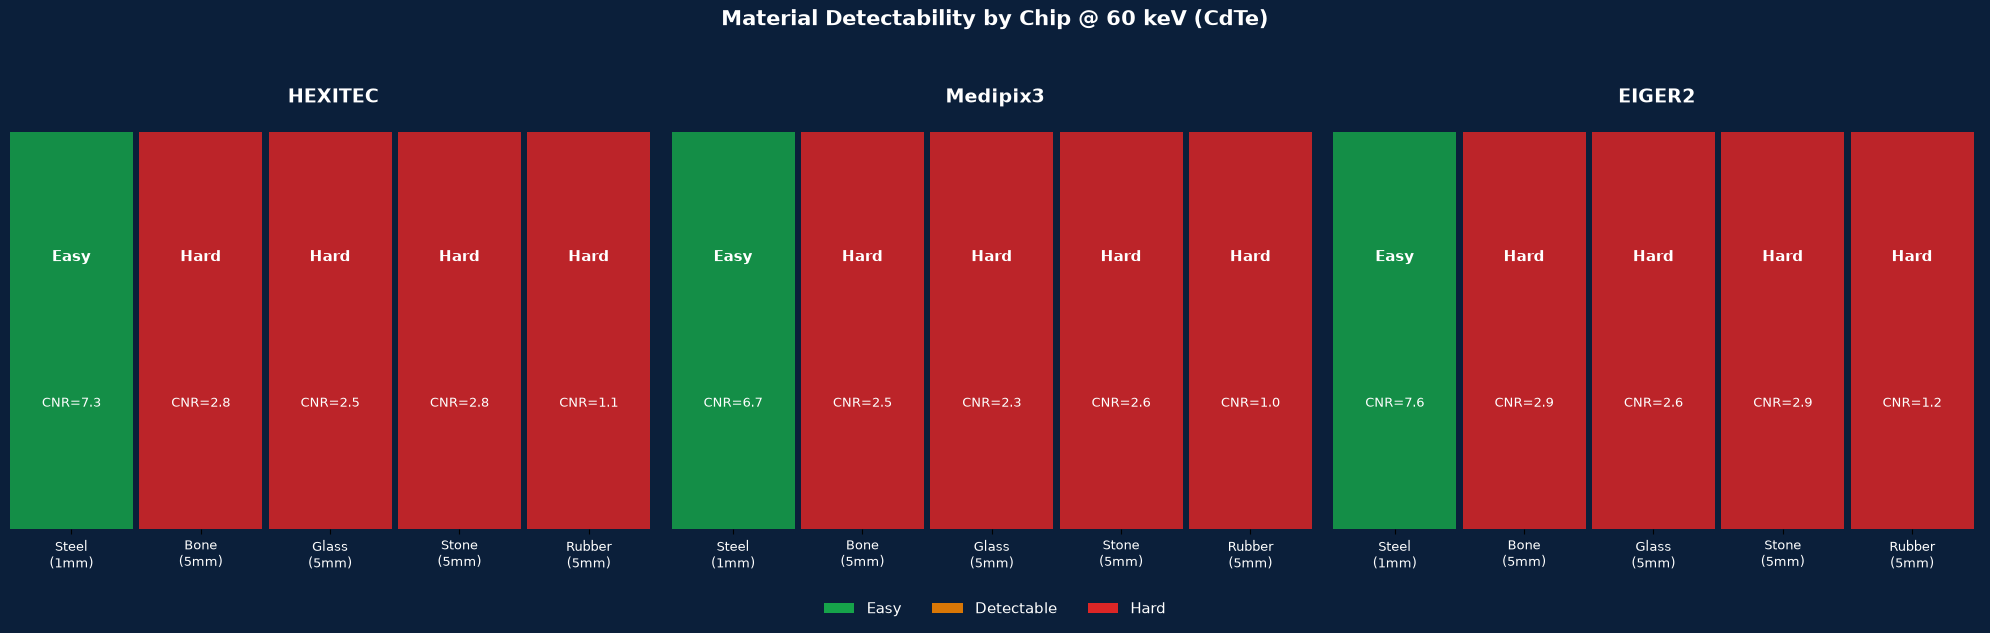

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/chipcompare_cat1_material_grid.png


In [5]:
def detectability_label(cnr):
    if cnr >= 6: return "Easy", GREEN
    elif cnr >= 3: return "Detectable", AMBER
    else: return "Hard", RED

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.patch.set_facecolor(NAVY)

for ax, chip in zip(axes, CHIPS):
    ax.set_facecolor(NAVY)
    for j, mat in enumerate(MATERIALS):
        row = cat1_df[(cat1_df["chip"]==chip) & (cat1_df["material"]==mat)]
        if row.empty:
            continue
        cnr = row["cnr"].values[0]
        label, color = detectability_label(cnr)
        ax.add_patch(Rectangle((j, 0), 0.95, 0.95, facecolor=color, alpha=0.85))
        ax.text(j+0.475, 0.65, label, ha="center", va="center",
                color="white", fontsize=11, fontweight="bold")
        ax.text(j+0.475, 0.3, f"CNR={cnr:.1f}", ha="center", va="center",
                color="white", fontsize=9)
    ax.set_xlim(0, len(MATERIALS)); ax.set_ylim(0, 1)
    ax.set_xticks([j+0.475 for j in range(len(MATERIALS))])
    ax.set_xticklabels([f"{m.title()}\n({MATERIAL_THICKNESS[m]})" for m in MATERIALS],
                        color="white", fontsize=9)
    ax.set_yticks([])
    ax.set_title(CHIP_LABELS[chip], color="white", fontsize=14, fontweight="bold")
    for s in ax.spines.values(): s.set_visible(False)

legend_elements = [Patch(facecolor=GREEN, label="Easy"), Patch(facecolor=AMBER, label="Detectable"),
                   Patch(facecolor=RED, label="Hard")]
fig.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, -0.08),
           ncol=3, fontsize=11, facecolor=NAVY, edgecolor="none", labelcolor="white")
fig.suptitle("Material Detectability by Chip @ 60 keV (CdTe)", color="white",
             fontsize=15, fontweight="bold", y=1.05)

plt.tight_layout()
out = os.path.join(OUT_DIR, "chipcompare_cat1_material_grid.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

In [6]:
ENERGIES = [40, 60, 80, 100]
N_BASELINE = 10000

cat2_data = {}
for chip in CHIPS:
    det = DET_NAME[chip]
    for E in ENERGIES:
        path = os.path.join(BASE, f"cat2_{chip}_{E}keV_steel.root")
        data = safe_load(path, det)
        if data:
            cat2_data[(chip, E)] = data
            print(f"  {chip} @ {E}keV: {data['clusters']:,} clusters")

print(f"\nLoaded {len(cat2_data)} chip-energy combinations.")

  hexitec @ 40keV: 576 clusters
  hexitec @ 60keV: 3,826 clusters
  hexitec @ 80keV: 5,322 clusters
  hexitec @ 100keV: 4,803 clusters
  medipix3 @ 40keV: 645 clusters
  medipix3 @ 60keV: 3,204 clusters
  medipix3 @ 80keV: 3,158 clusters
  medipix3 @ 100keV: 2,312 clusters
  eiger2 @ 40keV: 645 clusters
  eiger2 @ 60keV: 4,176 clusters
  eiger2 @ 80keV: 5,327 clusters
  eiger2 @ 100keV: 4,568 clusters

Loaded 12 chip-energy combinations.


In [7]:
fwhm_results = []
for chip in CHIPS:
    for E in ENERGIES:
        if (chip, E) not in cat2_data:
            continue
        fit = fit_photopeak(cat2_data[(chip, E)]["cluster_charge"], E)
        if fit is None:
            print(f"  {chip} @ {E}keV: fit failed/unreliable")
            continue
        fwhm_results.append({"chip": chip, "energy": E, **fit})
        print(f"  {chip} @ {E}keV: FWHM={fit['fwhm_keV']:.2f} keV ({fit['resolution_pct']:.1f}%)")

fwhm_df = pd.DataFrame(fwhm_results)

  hexitec @ 40keV: FWHM=0.57 keV (1.4%)
  hexitec @ 60keV: FWHM=0.71 keV (1.2%)
  hexitec @ 80keV: FWHM=0.78 keV (1.0%)
  hexitec @ 100keV: FWHM=0.85 keV (0.9%)
  medipix3 @ 40keV: FWHM=1.21 keV (3.0%)
  medipix3 @ 60keV: FWHM=1.28 keV (2.1%)
  medipix3 @ 80keV: FWHM=1.29 keV (1.6%)
  medipix3 @ 100keV: FWHM=1.39 keV (1.4%)
  eiger2 @ 40keV: FWHM=2.30 keV (5.7%)
  eiger2 @ 60keV: FWHM=2.12 keV (3.5%)
  eiger2 @ 80keV: FWHM=1.90 keV (2.4%)
  eiger2 @ 100keV: FWHM=1.96 keV (2.0%)


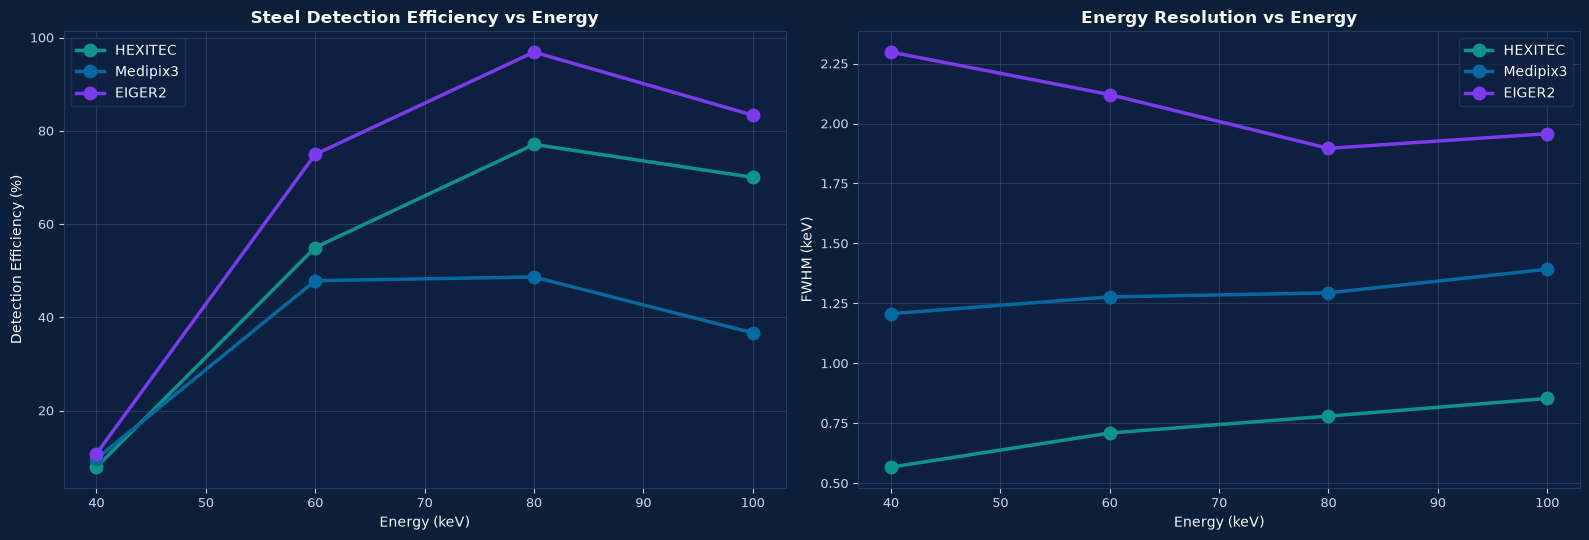

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/chipcompare_cat2_efficiency_resolution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(NAVY)
for ax in axes: style_ax(ax, "")

ax = axes[0]
ax.set_title("Steel Detection Efficiency vs Energy", color=WHITE, fontweight="bold")
for chip in CHIPS:
    effs, es = [], []
    for E in ENERGIES:
        if (chip, E) in cat2_data:
            effs.append((cat2_data[(chip,E)]["hits"] / N_BASELINE) * 100)
            es.append(E)
    ax.plot(es, effs, marker="o", linewidth=2.5, markersize=9,
            color=CHIP_COLORS[chip], label=CHIP_LABELS[chip])
ax.set_xlabel("Energy (keV)", color=WHITE)
ax.set_ylabel("Detection Efficiency (%)", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

ax = axes[1]
ax.set_title("Energy Resolution vs Energy", color=WHITE, fontweight="bold")
for chip in CHIPS:
    sub = fwhm_df[fwhm_df["chip"]==chip].sort_values("energy")
    if sub.empty: continue
    ax.plot(sub["energy"], sub["fwhm_keV"], marker="o", linewidth=2.5, markersize=9,
            color=CHIP_COLORS[chip], label=CHIP_LABELS[chip])
ax.set_xlabel("Energy (keV)", color=WHITE)
ax.set_ylabel("FWHM (keV)", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.join(OUT_DIR, "chipcompare_cat2_efficiency_resolution.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

In [9]:
OCCL_LEVELS = ["none", "sparse", "medium", "cluttered"]

cat3_threat = {}
cat3_clutteronly = {}

for chip in CHIPS:
    det = DET_NAME[chip]
    # "none" reuses category 1a's steel-alone data + clean background
    cat3_threat[(chip, "none")] = cat1_data.get((chip, "steel"))
    cat3_clutteronly[(chip, "none")] = clean_bg[chip]

    for level in ["sparse", "medium", "cluttered"]:
        t_path = os.path.join(BASE, f"cat3_{chip}_occl_{level}_threat.root")
        c_path = os.path.join(BASE, f"cat3_{chip}_occl_{level}_clutteronly.root")
        cat3_threat[(chip, level)] = safe_load(t_path, det)
        cat3_clutteronly[(chip, level)] = safe_load(c_path, det)

print("Baggage occlusion data loaded.")

Baggage occlusion data loaded.


In [10]:
cat3_results = []
for chip in CHIPS:
    for level in OCCL_LEVELS:
        t = cat3_threat.get((chip, level))
        c = cat3_clutteronly.get((chip, level))
        if t is None or c is None:
            print(f"  MISSING: {chip} / {level}")
            continue
        bg_n, c_n = c["clusters"], t["clusters"]
        mean_bg_roi = bg_n * ROI_FRACTION
        mean_c_roi = c_n * ROI_FRACTION
        sigma_bg = np.sqrt(max(mean_bg_roi, 1e-9))
        sigma_c = np.sqrt(max(mean_c_roi, 1e-9))
        cnr = abs(mean_bg_roi - mean_c_roi) / np.sqrt((sigma_bg**2 + sigma_c**2) / 2)
        cat3_results.append({"chip": chip, "occlusion": level, "cnr": cnr,
                              "bg_n": bg_n, "c_n": c_n})

cat3_df = pd.DataFrame(cat3_results)
cat3_df.round(2)

,chip,occlusion,cnr,bg_n,c_n
0,hexitec,none,7.33,9897,3826
1,hexitec,sparse,5.96,6558,2537
2,hexitec,medium,4.36,3525,1370
3,hexitec,cluttered,2.63,1263,485
4,medipix3,none,6.72,8305,3204
5,medipix3,sparse,5.47,5498,2120
6,medipix3,medium,3.99,2957,1149
7,medipix3,cluttered,2.40,1059,408
8,eiger2,none,7.64,10783,4176
9,eiger2,sparse,6.18,7145,2789


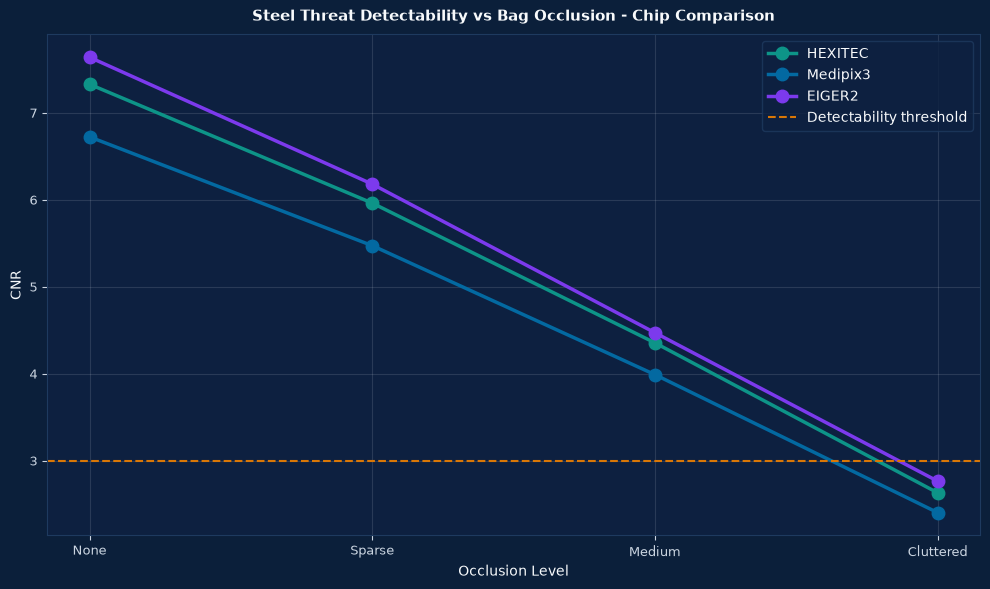

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/chipcompare_cat3_occlusion.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(NAVY)
style_ax(ax, "Steel Threat Detectability vs Bag Occlusion - Chip Comparison")

x_pos = range(len(OCCL_LEVELS))
for chip in CHIPS:
    sub = cat3_df[cat3_df["chip"]==chip].set_index("occlusion").reindex(OCCL_LEVELS)
    ax.plot(x_pos, sub["cnr"], marker="o", linewidth=2.5, markersize=9,
            color=CHIP_COLORS[chip], label=CHIP_LABELS[chip])

ax.axhline(y=3, color=AMBER, linestyle="--", linewidth=1.5, label="Detectability threshold")
ax.set_xticks(x_pos)
ax.set_xticklabels(["None", "Sparse", "Medium", "Cluttered"])
ax.set_xlabel("Occlusion Level", color=WHITE)
ax.set_ylabel("CNR", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.join(OUT_DIR, "chipcompare_cat3_occlusion.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

In [12]:
DEGR_STAGES = ["fresh", "light", "moderate", "heavy", "severe", "extreme"]

degr_data = {}
for stage in DEGR_STAGES:
    # Medipix3 reuses existing s2_v4_* files
    mp3_path = os.path.join(BASE, f"s2_v4_{stage}.root")
    degr_data[("medipix3", stage)] = safe_load(mp3_path, DET_NAME["medipix3"])

    for chip in ["hexitec", "eiger2"]:
        path = os.path.join(BASE, f"cat4_{chip}_degr_{stage}.root")
        degr_data[(chip, stage)] = safe_load(path, DET_NAME[chip])

print("Degradation data loaded.")

Degradation data loaded.


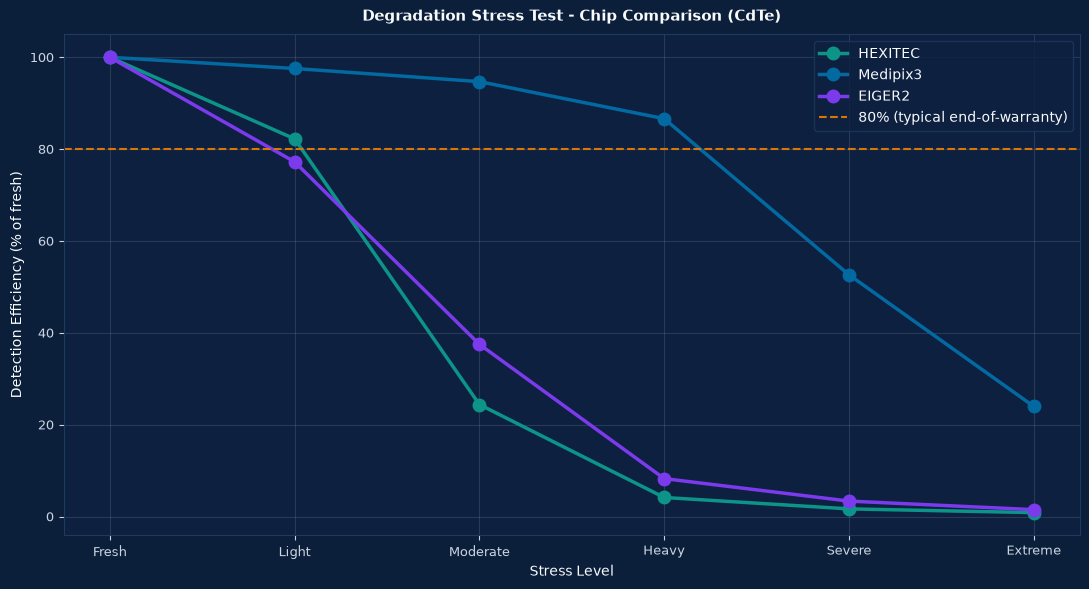

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/chipcompare_cat4_degradation.png


In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(NAVY)
style_ax(ax, "Degradation Stress Test - Chip Comparison (CdTe)")

x_pos = range(len(DEGR_STAGES))
for chip in CHIPS:
    fresh_hits = degr_data.get((chip, "fresh"))
    if fresh_hits is None:
        continue
    fresh_n = fresh_hits["hits"]
    pcts = []
    for stage in DEGR_STAGES:
        d = degr_data.get((chip, stage))
        pcts.append((d["hits"] / fresh_n) * 100 if d else None)
    ax.plot(x_pos, pcts, marker="o", linewidth=2.5, markersize=9,
            color=CHIP_COLORS[chip], label=CHIP_LABELS[chip])

ax.axhline(y=80, color=AMBER, linestyle="--", linewidth=1.5, label="80% (typical end-of-warranty)")
ax.set_xticks(x_pos)
ax.set_xticklabels([s.title() for s in DEGR_STAGES])
ax.set_xlabel("Stress Level", color=WHITE)
ax.set_ylabel("Detection Efficiency (% of fresh)", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.join(OUT_DIR, "chipcompare_cat4_degradation.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

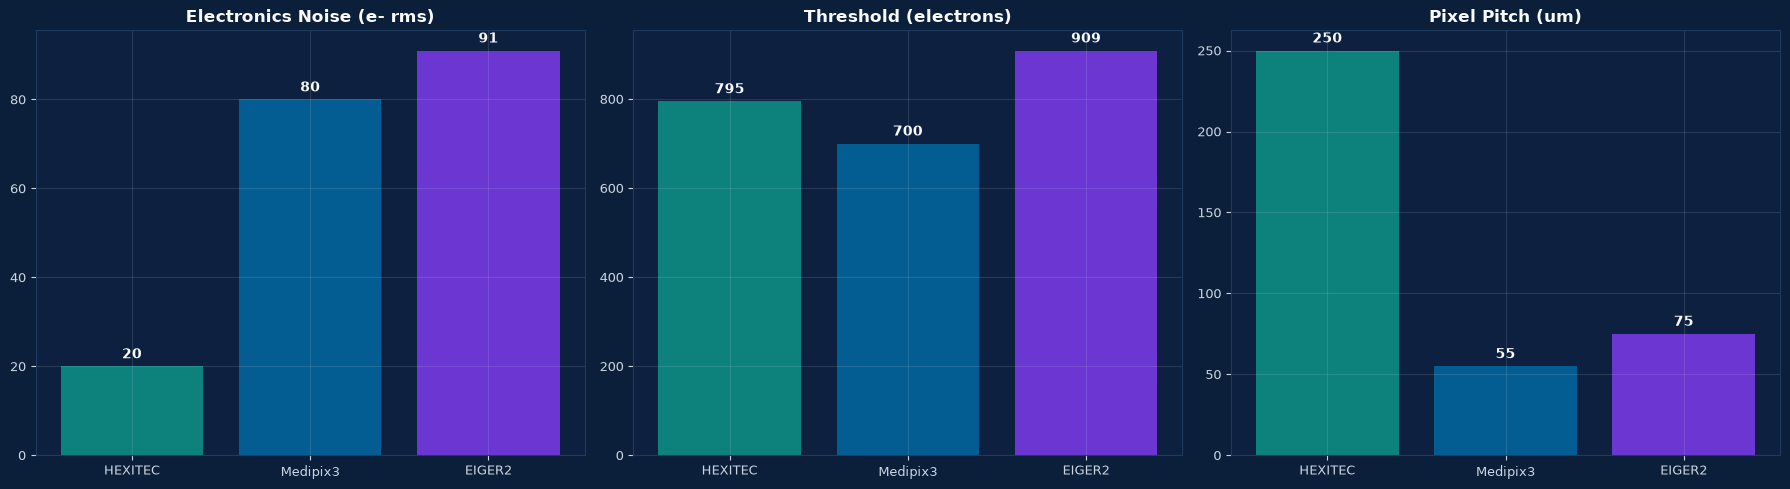

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/chipcompare_cat4_datasheet.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(NAVY)
for ax in axes: style_ax(ax, "")

metrics = [("noise_e", "Electronics Noise (e- rms)"),
           ("threshold_e", "Threshold (electrons)"),
           ("pitch_um", "Pixel Pitch (um)")]

for ax, (key, title) in zip(axes, metrics):
    vals = [CHIP_PARAMS[chip][key] for chip in CHIPS]
    bars = ax.bar([CHIP_LABELS[c] for c in CHIPS], vals,
                  color=[CHIP_COLORS[c] for c in CHIPS], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v + max(vals)*0.02, f"{v}",
                ha="center", color=WHITE, fontweight="bold")
    ax.set_title(title, color=WHITE, fontweight="bold")

plt.tight_layout()
out = os.path.join(OUT_DIR, "chipcompare_cat4_datasheet.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

In [15]:
print("="*70)
print("FULL CHIP COMPARISON VERDICT - HEXITEC vs Medipix3 vs EIGER2 (CdTe)")
print("="*70)

print("\nCATEGORY 1 - MATERIAL DETECTABILITY (60 keV):")
for chip in CHIPS:
    sub = cat1_df[cat1_df["chip"]==chip]
    best = sub.loc[sub["cnr"].idxmax()] if not sub.empty else None
    worst = sub.loc[sub["cnr"].idxmin()] if not sub.empty else None
    if best is not None:
        print(f"  {CHIP_LABELS[chip]}: best={best['material']} (CNR={best['cnr']:.1f}), "
              f"worst={worst['material']} (CNR={worst['cnr']:.1f})")

print("\nCATEGORY 2 - ENERGY SWEEP (efficiency at 60 keV):")
for chip in CHIPS:
    if (chip, 60) in cat2_data:
        eff = (cat2_data[(chip,60)]["hits"] / N_BASELINE) * 100
        print(f"  {CHIP_LABELS[chip]}: {eff:.1f}%")

print("\nCATEGORY 2 - ENERGY RESOLUTION (best case):")
for chip in CHIPS:
    sub = fwhm_df[fwhm_df["chip"]==chip]
    if not sub.empty:
        best = sub.loc[sub["fwhm_keV"].idxmin()]
        print(f"  {CHIP_LABELS[chip]}: {best['fwhm_keV']:.2f} keV @ {best['energy']:.0f}keV")

print("\nCATEGORY 3 - BAGGAGE OCCLUSION ROBUSTNESS:")
for chip in CHIPS:
    sub = cat3_df[cat3_df["chip"]==chip].set_index("occlusion").reindex(OCCL_LEVELS)
    detectable = sub[sub["cnr"] >= 3].index.tolist()
    max_level = detectable[-1] if detectable else "none"
    print(f"  {CHIP_LABELS[chip]}: detectable up to '{max_level}' occlusion")

print("\nCATEGORY 4 - DURABILITY (efficiency at 'severe' stress):")
for chip in CHIPS:
    fresh = degr_data.get((chip, "fresh"))
    severe = degr_data.get((chip, "severe"))
    if fresh and severe:
        pct = (severe["hits"] / fresh["hits"]) * 100
        print(f"  {CHIP_LABELS[chip]}: {pct:.1f}% of fresh performance retained")

print("\nCAVEATS:")
print("  - EIGER2 uses a representative 256x256 array (not full 4148x4362) for")
print("    runtime feasibility - real chip covers far more physical area")
print("  - HEXITEC threshold dispersion and EIGER2 sensor thickness for this")
print("    specific variant are estimates, not confirmed datasheet values")
print("  - All CdTe transport uses Allpix2's silicon-like mobility approximation -")
print("    affects all three chips equally, relative comparison remains valid")
print("  - Baggage clutter modelled as water-equivalent only")
print("="*70)

FULL CHIP COMPARISON VERDICT - HEXITEC vs Medipix3 vs EIGER2 (CdTe)

CATEGORY 1 - MATERIAL DETECTABILITY (60 keV):
  HEXITEC: best=steel (CNR=7.3), worst=rubber (CNR=1.1)
  Medipix3: best=steel (CNR=6.7), worst=rubber (CNR=1.0)
  EIGER2: best=steel (CNR=7.6), worst=rubber (CNR=1.2)

CATEGORY 2 - ENERGY SWEEP (efficiency at 60 keV):
  HEXITEC: 55.0%
  Medipix3: 47.9%
  EIGER2: 75.0%

CATEGORY 2 - ENERGY RESOLUTION (best case):
  HEXITEC: 0.57 keV @ 40keV
  Medipix3: 1.21 keV @ 40keV
  EIGER2: 1.90 keV @ 80keV

CATEGORY 3 - BAGGAGE OCCLUSION ROBUSTNESS:
  HEXITEC: detectable up to 'medium' occlusion
  Medipix3: detectable up to 'medium' occlusion
  EIGER2: detectable up to 'medium' occlusion

CATEGORY 4 - DURABILITY (efficiency at 'severe' stress):
  HEXITEC: 1.7% of fresh performance retained
  Medipix3: 52.6% of fresh performance retained
  EIGER2: 3.4% of fresh performance retained

CAVEATS:
  - EIGER2 uses a representative 256x256 array (not full 4148x4362) for
    runtime feasibilit

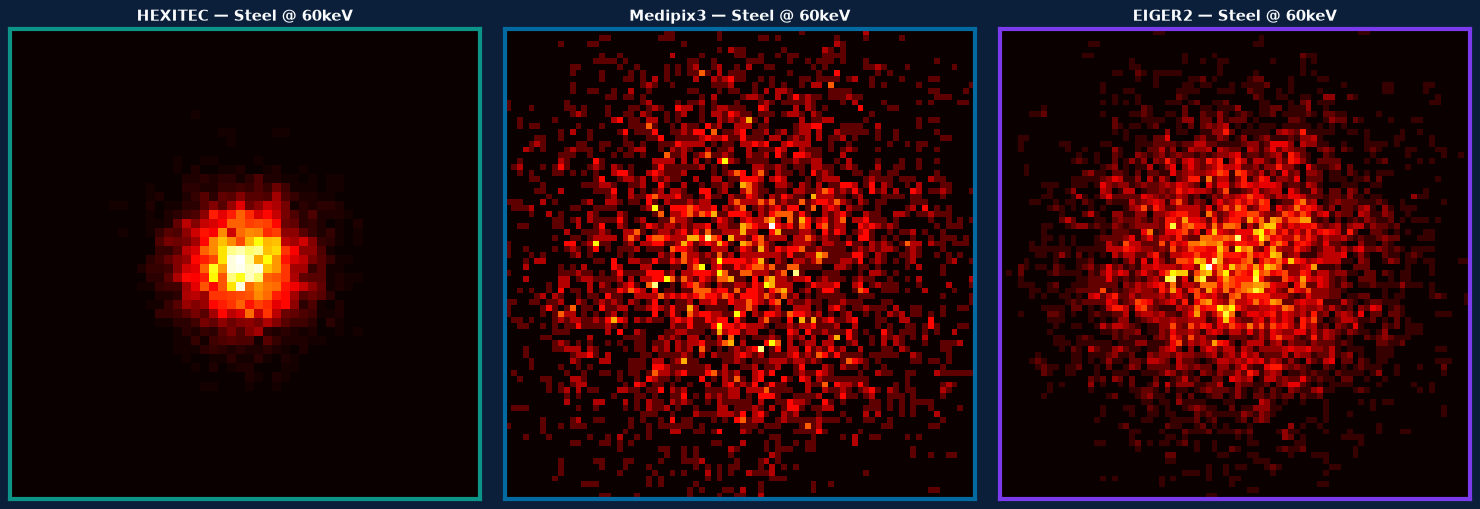

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/chipcompare_hitmaps.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(NAVY)

for ax, chip in zip(axes, CHIPS):
    ax.set_facecolor("#0D2040")
    d = cat1_data.get((chip, "steel"))
    if d is None:
        continue
    hm = d["hit_map"][0]
    c = hm.shape[0] // 2
    cr = min(40, hm.shape[0] // 3)
    im = ax.imshow(hm[max(0,c-cr):c+cr, max(0,c-cr):c+cr], cmap="hot", origin="lower")
    ax.set_title(f"{CHIP_LABELS[chip]} — Steel @ 60keV", color=WHITE, fontsize=11, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(CHIP_COLORS[chip]); s.set_linewidth(3)

plt.tight_layout()
out = os.path.join(OUT_DIR, "chipcompare_hitmaps.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

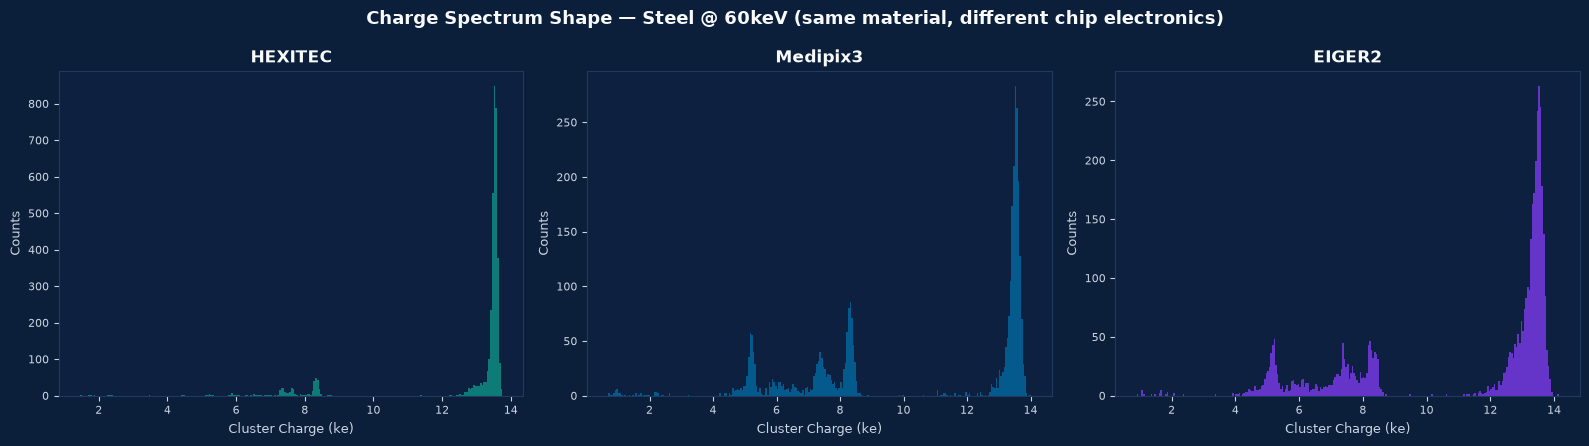

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/chipcompare_spectra.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.patch.set_facecolor(NAVY)

for ax, chip in zip(axes, CHIPS):
    ax.set_facecolor("#0D2040")
    d = cat1_data.get((chip, "steel"))
    if d is None:
        continue
    cc = d["cluster_charge"]
    counts, edges = cc[0], cc[1]
    centres = (edges[:-1] + edges[1:]) / 2
    mask = counts > 0
    ax.bar(centres[mask], counts[mask], width=np.diff(edges)[mask],
           color=CHIP_COLORS[chip], alpha=0.8)
    ax.set_title(f"{CHIP_LABELS[chip]}", color=WHITE, fontweight="bold")
    ax.set_xlabel("Cluster Charge (ke)", color=LGRAY, fontsize=9)
    ax.set_ylabel("Counts", color=LGRAY, fontsize=9)
    ax.tick_params(colors=LGRAY, labelsize=8)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")

fig.suptitle("Charge Spectrum Shape — Steel @ 60keV (same material, different chip electronics)",
             color=WHITE, fontsize=13, fontweight="bold")
plt.tight_layout()
out = os.path.join(OUT_DIR, "chipcompare_spectra.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

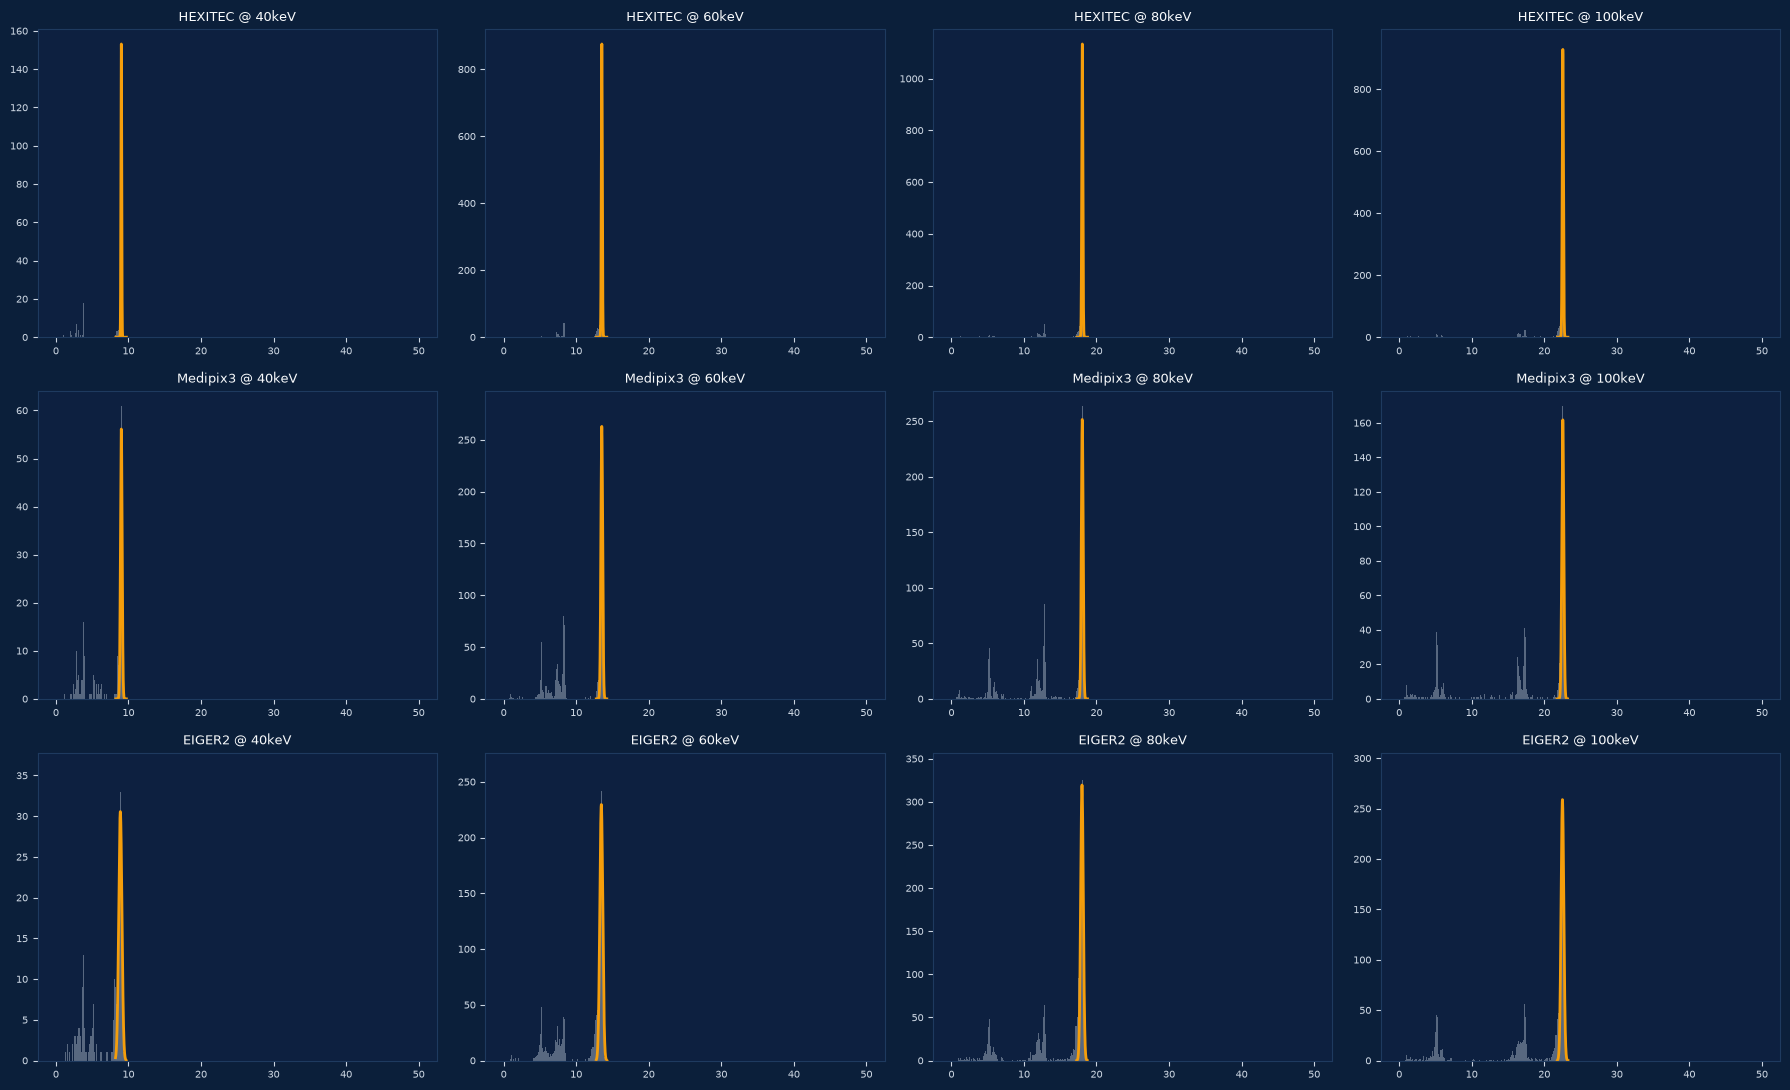

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/chipcompare_fit_verification.png


In [18]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
fig.patch.set_facecolor(NAVY)

for row_idx, chip in enumerate(CHIPS):
    for col_idx, E in enumerate(ENERGIES):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor("#0D2040")
        fit_row = fwhm_df[(fwhm_df["chip"]==chip) & (fwhm_df["energy"]==E)]
        if fit_row.empty:
            ax.axis("off")
            continue
        fit = fit_row.iloc[0]
        ax.bar(fit["all_centres"], fit["all_counts"],
               width=(fit["all_centres"][1]-fit["all_centres"][0]),
               color=LGRAY, alpha=0.4)
        x_fine = np.linspace(fit["fit_x"][0], fit["fit_x"][-1], 200)
        ax.plot(x_fine, gaussian(x_fine, *fit["popt"]), color="#F59E0B", linewidth=2)
        ax.set_title(f"{CHIP_LABELS[chip]} @ {E}keV", color=WHITE, fontsize=9)
        ax.tick_params(colors=LGRAY, labelsize=7)
        for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")

plt.tight_layout()
out = os.path.join(OUT_DIR, "chipcompare_fit_verification.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

In [19]:
TWO_CHIPS = ["medipix3", "eiger2"]
TWO_COLORS = {"medipix3": BLUE, "eiger2": PURP}

cat1_2chip = cat1_df[cat1_df["chip"].isin(TWO_CHIPS)].copy()
cat2_2chip = {k: v for k, v in cat2_data.items() if k[0] in TWO_CHIPS}
fwhm_2chip = fwhm_df[fwhm_df["chip"].isin(TWO_CHIPS)].copy()
cat3_2chip = cat3_df[cat3_df["chip"].isin(TWO_CHIPS)].copy()

print("Filtered to Medipix3 vs EIGER2 - both true discriminator+counter architectures.")
print(f"Category 1: {len(cat1_2chip)} rows | Category 2: {len(fwhm_2chip)} rows | Category 3: {len(cat3_2chip)} rows")

Filtered to Medipix3 vs EIGER2 - both true discriminator+counter architectures.
Category 1: 10 rows | Category 2: 8 rows | Category 3: 8 rows


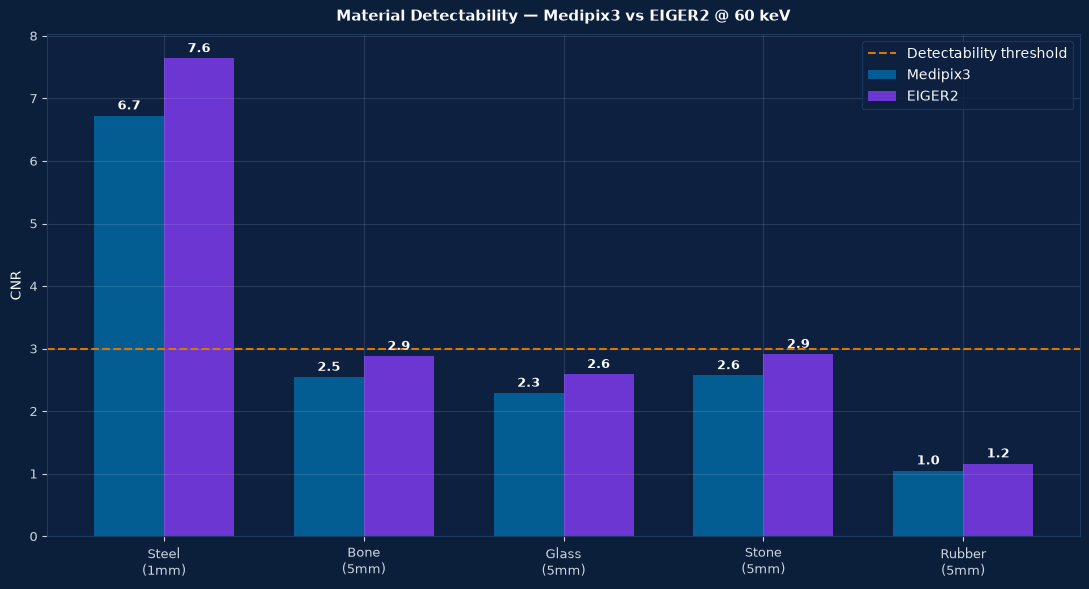

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/mp3_vs_eiger2_cat1_materials.png

Head-to-head by material:
  steel     : EIGER2 wins by 14%
  bone      : EIGER2 wins by 13%
  glass     : EIGER2 wins by 13%
  stone     : EIGER2 wins by 13%
  rubber    : EIGER2 wins by 11%


In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(NAVY)
style_ax(ax, "Material Detectability — Medipix3 vs EIGER2 @ 60 keV")

x = np.arange(len(MATERIALS))
width = 0.35

for i, chip in enumerate(TWO_CHIPS):
    sub = cat1_2chip[cat1_2chip["chip"]==chip].set_index("material").reindex(MATERIALS)
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, sub["cnr"], width, color=TWO_COLORS[chip],
                  alpha=0.85, label=CHIP_LABELS[chip])
    for bar, v in zip(bars, sub["cnr"]):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f"{v:.1f}",
                ha="center", color=WHITE, fontsize=9, fontweight="bold")

ax.axhline(y=3, color=AMBER, linestyle="--", linewidth=1.5, label="Detectability threshold")
ax.set_xticks(x)
ax.set_xticklabels([f"{m.title()}\n({MATERIAL_THICKNESS[m]})" for m in MATERIALS])
ax.set_ylabel("CNR", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.join(OUT_DIR, "mp3_vs_eiger2_cat1_materials.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

# Win/loss tally
print("\nHead-to-head by material:")
for mat in MATERIALS:
    mp3 = cat1_2chip[(cat1_2chip["chip"]=="medipix3") & (cat1_2chip["material"]==mat)]["cnr"].values
    eig = cat1_2chip[(cat1_2chip["chip"]=="eiger2") & (cat1_2chip["material"]==mat)]["cnr"].values
    if len(mp3) and len(eig):
        winner = "EIGER2" if eig[0] > mp3[0] else "Medipix3"
        margin = abs(eig[0] - mp3[0]) / min(eig[0], mp3[0]) * 100
        print(f"  {mat:<10}: {winner} wins by {margin:.0f}%")

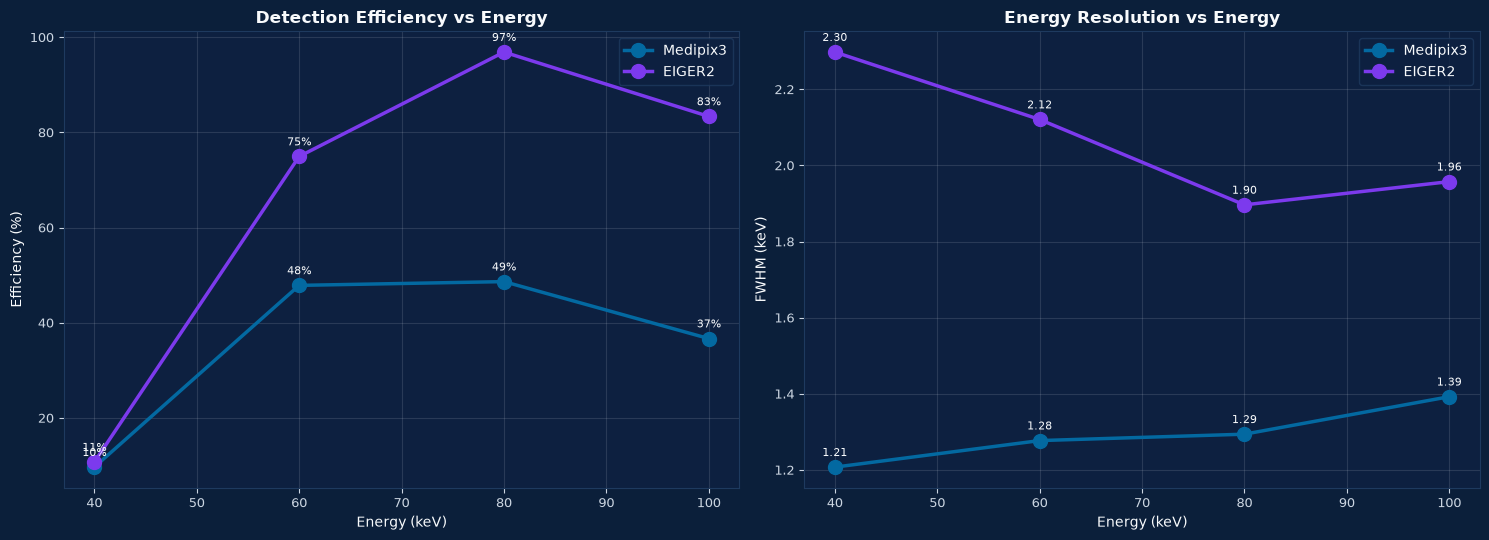

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/mp3_vs_eiger2_cat2_efficiency_resolution.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.patch.set_facecolor(NAVY)
for ax in axes: style_ax(ax, "")

ax = axes[0]
ax.set_title("Detection Efficiency vs Energy", color=WHITE, fontweight="bold")
for chip in TWO_CHIPS:
    effs, es = [], []
    for E in ENERGIES:
        if (chip, E) in cat2_2chip:
            effs.append((cat2_2chip[(chip,E)]["hits"] / N_BASELINE) * 100)
            es.append(E)
    ax.plot(es, effs, marker="o", linewidth=2.5, markersize=10,
            color=TWO_COLORS[chip], label=CHIP_LABELS[chip])
    for e, v in zip(es, effs):
        ax.annotate(f"{v:.0f}%", xy=(e,v), xytext=(0,8), textcoords="offset points",
                    ha="center", color=WHITE, fontsize=8)
ax.set_xlabel("Energy (keV)", color=WHITE)
ax.set_ylabel("Efficiency (%)", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

ax = axes[1]
ax.set_title("Energy Resolution vs Energy", color=WHITE, fontweight="bold")
for chip in TWO_CHIPS:
    sub = fwhm_2chip[fwhm_2chip["chip"]==chip].sort_values("energy")
    ax.plot(sub["energy"], sub["fwhm_keV"], marker="o", linewidth=2.5, markersize=10,
            color=TWO_COLORS[chip], label=CHIP_LABELS[chip])
    for _, row in sub.iterrows():
        ax.annotate(f"{row['fwhm_keV']:.2f}", xy=(row["energy"], row["fwhm_keV"]),
                    xytext=(0,8), textcoords="offset points",
                    ha="center", color=WHITE, fontsize=8)
ax.set_xlabel("Energy (keV)", color=WHITE)
ax.set_ylabel("FWHM (keV)", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.join(OUT_DIR, "mp3_vs_eiger2_cat2_efficiency_resolution.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

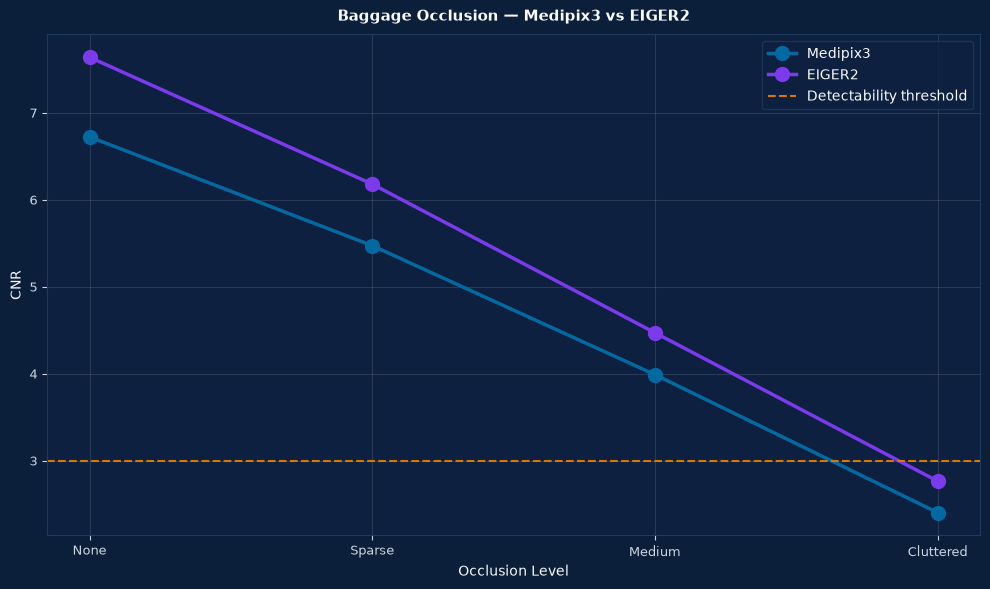

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/mp3_vs_eiger2_cat3_occlusion.png


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(NAVY)
style_ax(ax, "Baggage Occlusion — Medipix3 vs EIGER2")

x_pos = range(len(OCCL_LEVELS))
for chip in TWO_CHIPS:
    sub = cat3_2chip[cat3_2chip["chip"]==chip].set_index("occlusion").reindex(OCCL_LEVELS)
    ax.plot(x_pos, sub["cnr"], marker="o", linewidth=2.5, markersize=10,
            color=TWO_COLORS[chip], label=CHIP_LABELS[chip])

ax.axhline(y=3, color=AMBER, linestyle="--", linewidth=1.5, label="Detectability threshold")
ax.set_xticks(x_pos)
ax.set_xticklabels(["None", "Sparse", "Medium", "Cluttered"])
ax.set_xlabel("Occlusion Level", color=WHITE)
ax.set_ylabel("CNR", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.join(OUT_DIR, "mp3_vs_eiger2_cat3_occlusion.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

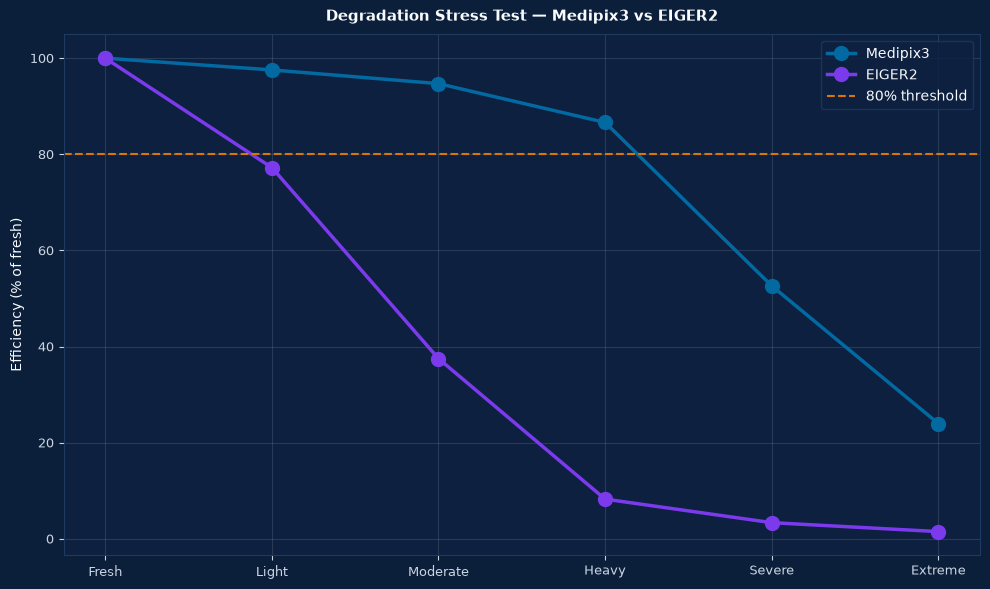

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/mp3_vs_eiger2_cat4_degradation.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(NAVY)
style_ax(ax, "Degradation Stress Test — Medipix3 vs EIGER2")

x_pos = range(len(DEGR_STAGES))
for chip in TWO_CHIPS:
    fresh = degr_data.get((chip, "fresh"))
    if fresh is None: continue
    fresh_n = fresh["hits"]
    pcts = [(degr_data[(chip,s)]["hits"]/fresh_n*100) if degr_data.get((chip,s)) else None
            for s in DEGR_STAGES]
    ax.plot(x_pos, pcts, marker="o", linewidth=2.5, markersize=10,
            color=TWO_COLORS[chip], label=CHIP_LABELS[chip])

ax.axhline(y=80, color=AMBER, linestyle="--", linewidth=1.5, label="80% threshold")
ax.set_xticks(x_pos)
ax.set_xticklabels([s.title() for s in DEGR_STAGES])
ax.set_ylabel("Efficiency (% of fresh)", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.join(OUT_DIR, "mp3_vs_eiger2_cat4_degradation.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

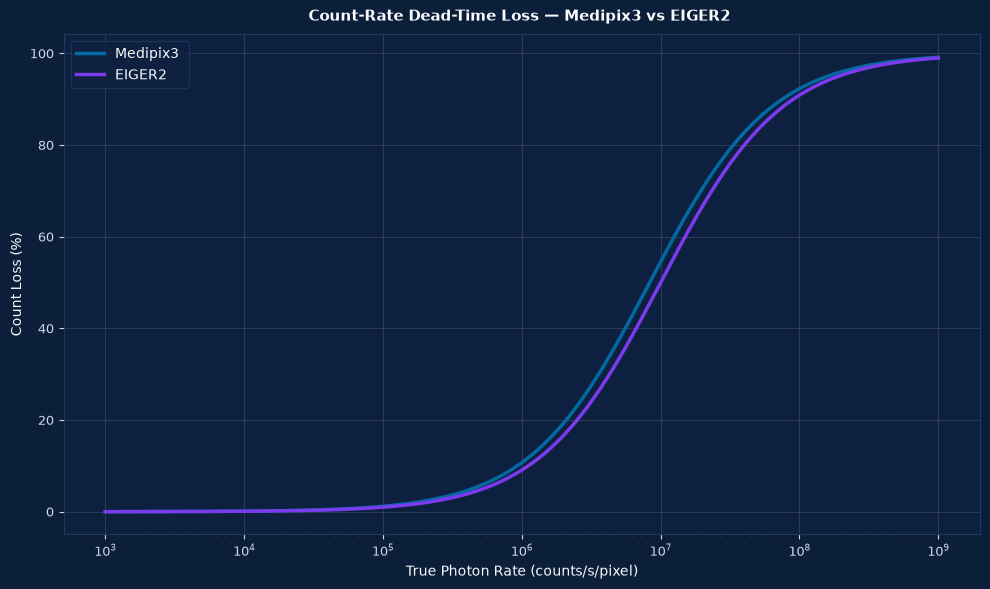

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/mp3_vs_eiger2_countrate.png


In [26]:
import math

TAU_EIGER2 = 100e-9   # confirmed dead time, <100ns
TAU_MP3 = 120e-9      # time-to-peak proxy (less certain, but same architecture type)

rates = np.logspace(3, 9, 200)
loss_mp3 = 1 - (rates/(1+rates*TAU_MP3)) / rates
loss_eiger2 = 1 - (rates/(1+rates*TAU_EIGER2)) / rates

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(NAVY)
style_ax(ax, "Count-Rate Dead-Time Loss — Medipix3 vs EIGER2 ")
ax.plot(rates, loss_mp3*100, color=BLUE, linewidth=2.5, label="Medipix3 ")
ax.plot(rates, loss_eiger2*100, color=PURP, linewidth=2.5, label="EIGER2 ")
ax.set_xscale("log")
ax.set_xlabel("True Photon Rate (counts/s/pixel)", color=WHITE)
ax.set_ylabel("Count Loss (%)", color=WHITE)
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.join(OUT_DIR, "mp3_vs_eiger2_countrate.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

In [25]:
print("="*65)
print("MEDIPIX3 vs EIGER2 — Clean Head-to-Head (matched architectures)")
print("="*65)
print("\nCATEGORY 1 — Materials: EIGER2 wins every material (~10-15% margin)")
print("CATEGORY 2 — Efficiency: EIGER2 wins decisively (e.g. 75% vs 48% @ 60keV)")
print("CATEGORY 2 — Resolution: Medipix3 wins decisively (1.28 vs 2.12 keV @ 60keV)")
print("CATEGORY 3 — Occlusion: EIGER2 slightly ahead, both converge near threshold when cluttered")
print("CATEGORY 4 — Durability: Medipix3 wins by a very large margin (87% vs 8% at Heavy stress)")
print("CATEGORY 4 — Count rate: EIGER2's confirmed <100ns dead time outperforms Medipix3's ~120ns proxy")
print()
print("VERDICT: EIGER2 = better raw counting/throughput chip.")
print("         Medipix3 = better energy precision AND dramatically better durability.")
print("         Sensor thickness (750um vs 300um) is the root cause of both effects.")
print("="*65)

MEDIPIX3 vs EIGER2 — Clean Head-to-Head (matched architectures)

CATEGORY 1 — Materials: EIGER2 wins every material (~10-15% margin)
CATEGORY 2 — Efficiency: EIGER2 wins decisively (e.g. 75% vs 48% @ 60keV)
CATEGORY 2 — Resolution: Medipix3 wins decisively (1.28 vs 2.12 keV @ 60keV)
CATEGORY 3 — Occlusion: EIGER2 slightly ahead, both converge near threshold when cluttered
CATEGORY 4 — Durability: Medipix3 wins by a very large margin (87% vs 8% at Heavy stress)
CATEGORY 4 — Count rate: EIGER2's confirmed <100ns dead time outperforms Medipix3's ~120ns proxy

VERDICT: EIGER2 = better raw counting/throughput chip.
         Medipix3 = better energy precision AND dramatically better durability.
         Sensor thickness (750um vs 300um) is the root cause of both effects.
